# HOU53-bot
## Exploratory Data Analysis (EDA)

In this notebook we will perform an exploratory analysis of the Ames Housing dataset. We will study the structure of the dataset, its variables and their distributions. We will also analyze correlations between variables and their relationship with the target variable `SalePrice`. The conclusions will guide the preprocessing decisions in the next notebook.

## Library Imports

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## File Paths

In [49]:
DATA = "data/raw/house_prices.csv"

## Load Data

In [50]:
df = pd.read_csv(DATA, na_values=['?', 'NA'])

display(df)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Exploratory Data Analysis

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [52]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [53]:
df[df.columns.tolist()].nunique().sort_values()

Alley            2
Street           2
Utilities        2
CentralAir       2
MasVnrType       3
              ... 
1stFlrSF       753
BsmtUnfSF      780
GrLivArea      861
LotArea       1073
Id            1460
Length: 81, dtype: int64

In [54]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 0


In [55]:
nulls = df.isnull().sum().sort_values(ascending=False) # Check for null values and sort them in descending order

pd.DataFrame({'Nulls': nulls, '% of nulls': (nulls / len(df) * 100).round(2)})

,Nulls,% of nulls
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
...,...,...
MoSold,0,0.00
YrSold,0,0.00
SaleType,0,0.00
SaleCondition,0,0.00


In [64]:
def detect_outliers_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    return col[(col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)].index.tolist()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outliers_dict = {col: detect_outliers_iqr(df[col]) for col in numeric_cols if len(detect_outliers_iqr(df[col])) > 0}

for col, vals in outliers_dict.items():
    print(f"{col}: {len(vals)} outliers → indices {vals}")

MSSubClass: 103 outliers → indices [9, 48, 56, 75, 87, 93, 115, 125, 145, 165, 172, 180, 193, 195, 225, 227, 232, 235, 243, 246, 285, 291, 300, 312, 335, 344, 348, 363, 411, 430, 432, 434, 472, 488, 489, 490, 500, 504, 520, 535, 578, 599, 603, 614, 623, 635, 637, 649, 655, 675, 685, 687, 703, 705, 713, 755, 758, 829, 831, 837, 861, 914, 915, 956, 959, 962, 969, 971, 975, 985, 1007, 1029, 1030, 1038, 1039, 1062, 1068, 1086, 1088, 1091, 1104, 1144, 1160, 1172, 1186, 1190, 1191, 1219, 1236, 1265, 1266, 1291, 1297, 1304, 1334, 1358, 1364, 1367, 1378, 1393, 1416, 1449, 1452]
LotFrontage: 88 outliers → indices [36, 41, 56, 75, 85, 86, 145, 150, 159, 171, 193, 195, 197, 225, 227, 231, 232, 235, 260, 276, 277, 290, 302, 306, 313, 363, 429, 430, 432, 434, 446, 489, 500, 504, 523, 599, 614, 649, 655, 662, 675, 758, 807, 825, 829, 837, 889, 906, 909, 915, 934, 956, 959, 962, 963, 966, 991, 1007, 1010, 1029, 1038, 1039, 1061, 1088, 1091, 1104, 1106, 1107, 1127, 1151, 1160, 1168, 1169, 1173, 1182, 

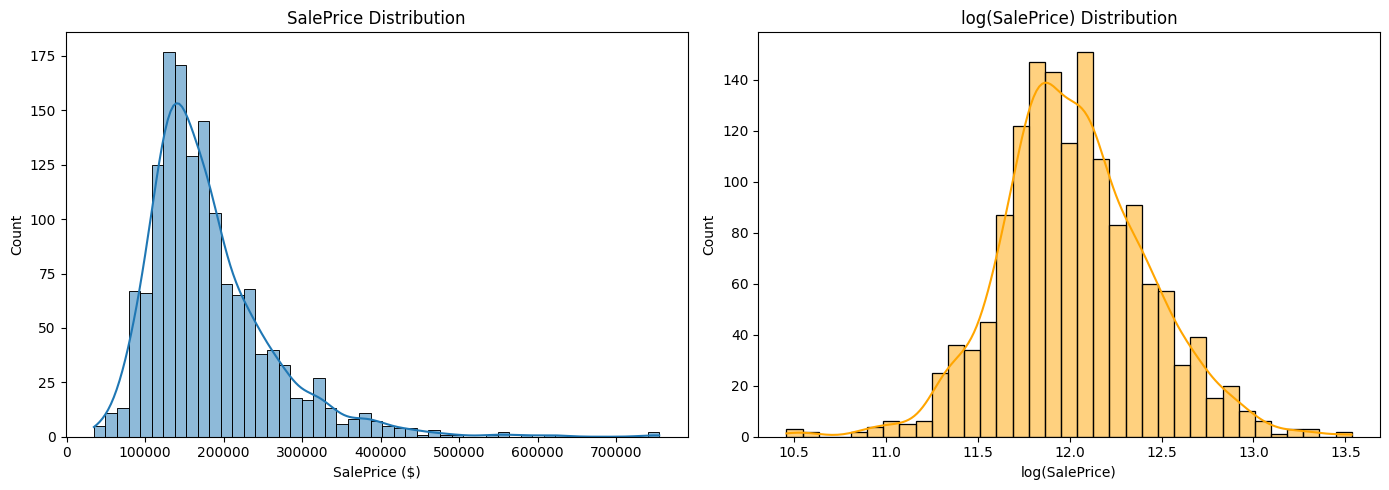

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('SalePrice ($)')

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='orange')
axes[1].set_title('log(SalePrice) Distribution')
axes[1].set_xlabel('log(SalePrice)')

plt.tight_layout()
plt.show()

print(df['SalePrice'].describe())

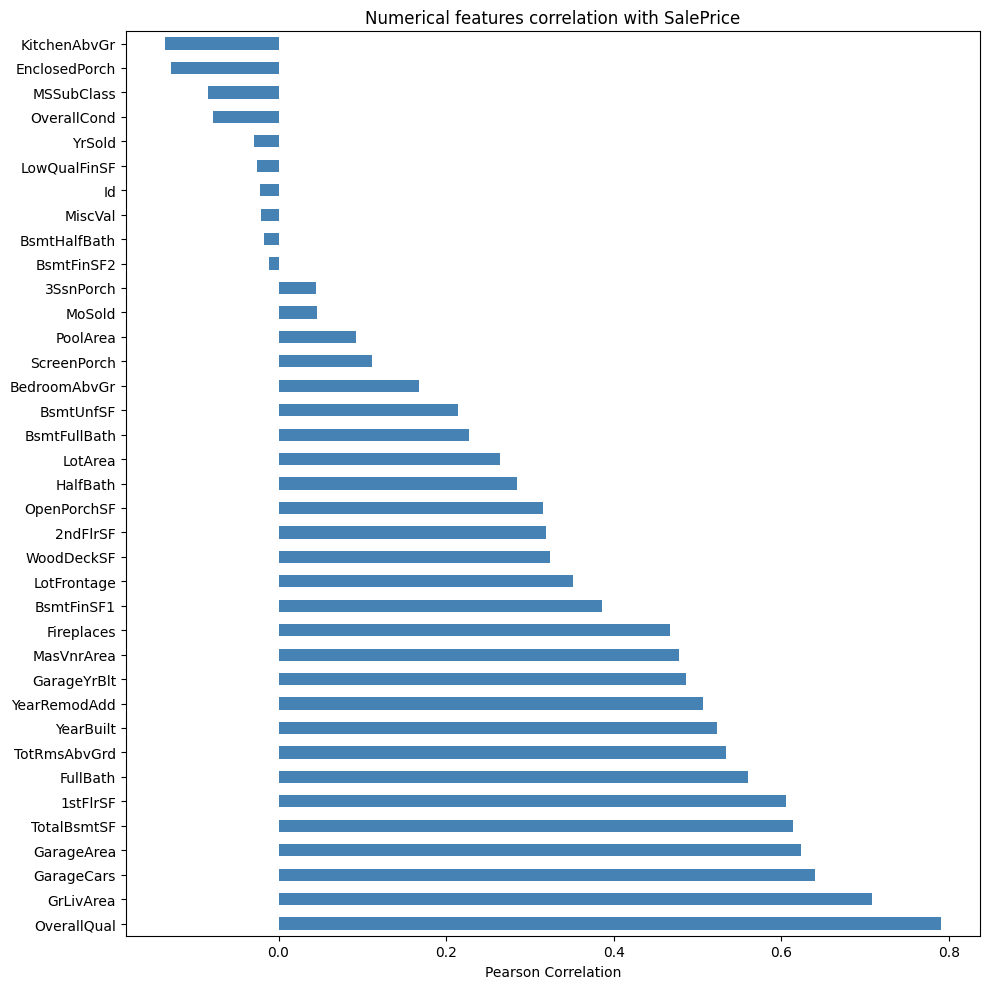

Top 10 features most correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [58]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

plt.figure(figsize=(10, 10))
correlations.plot(kind='barh', color='steelblue')
plt.title('Numerical features correlation with SalePrice')
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

print("Top 10 features most correlated with SalePrice:")
print(correlations.head(10).to_string())

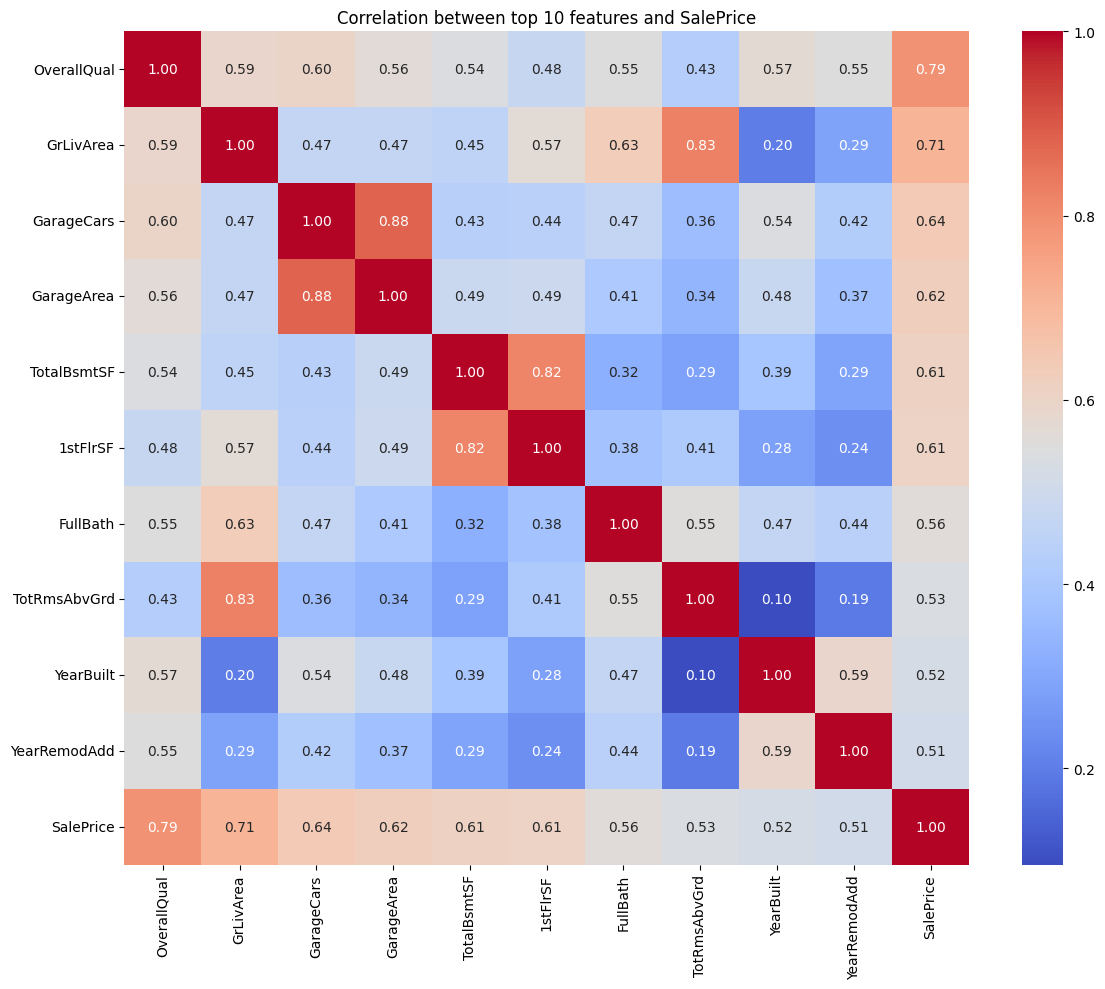

In [59]:
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('SalePrice')

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between top 10 features and SalePrice')
plt.tight_layout()
plt.show()

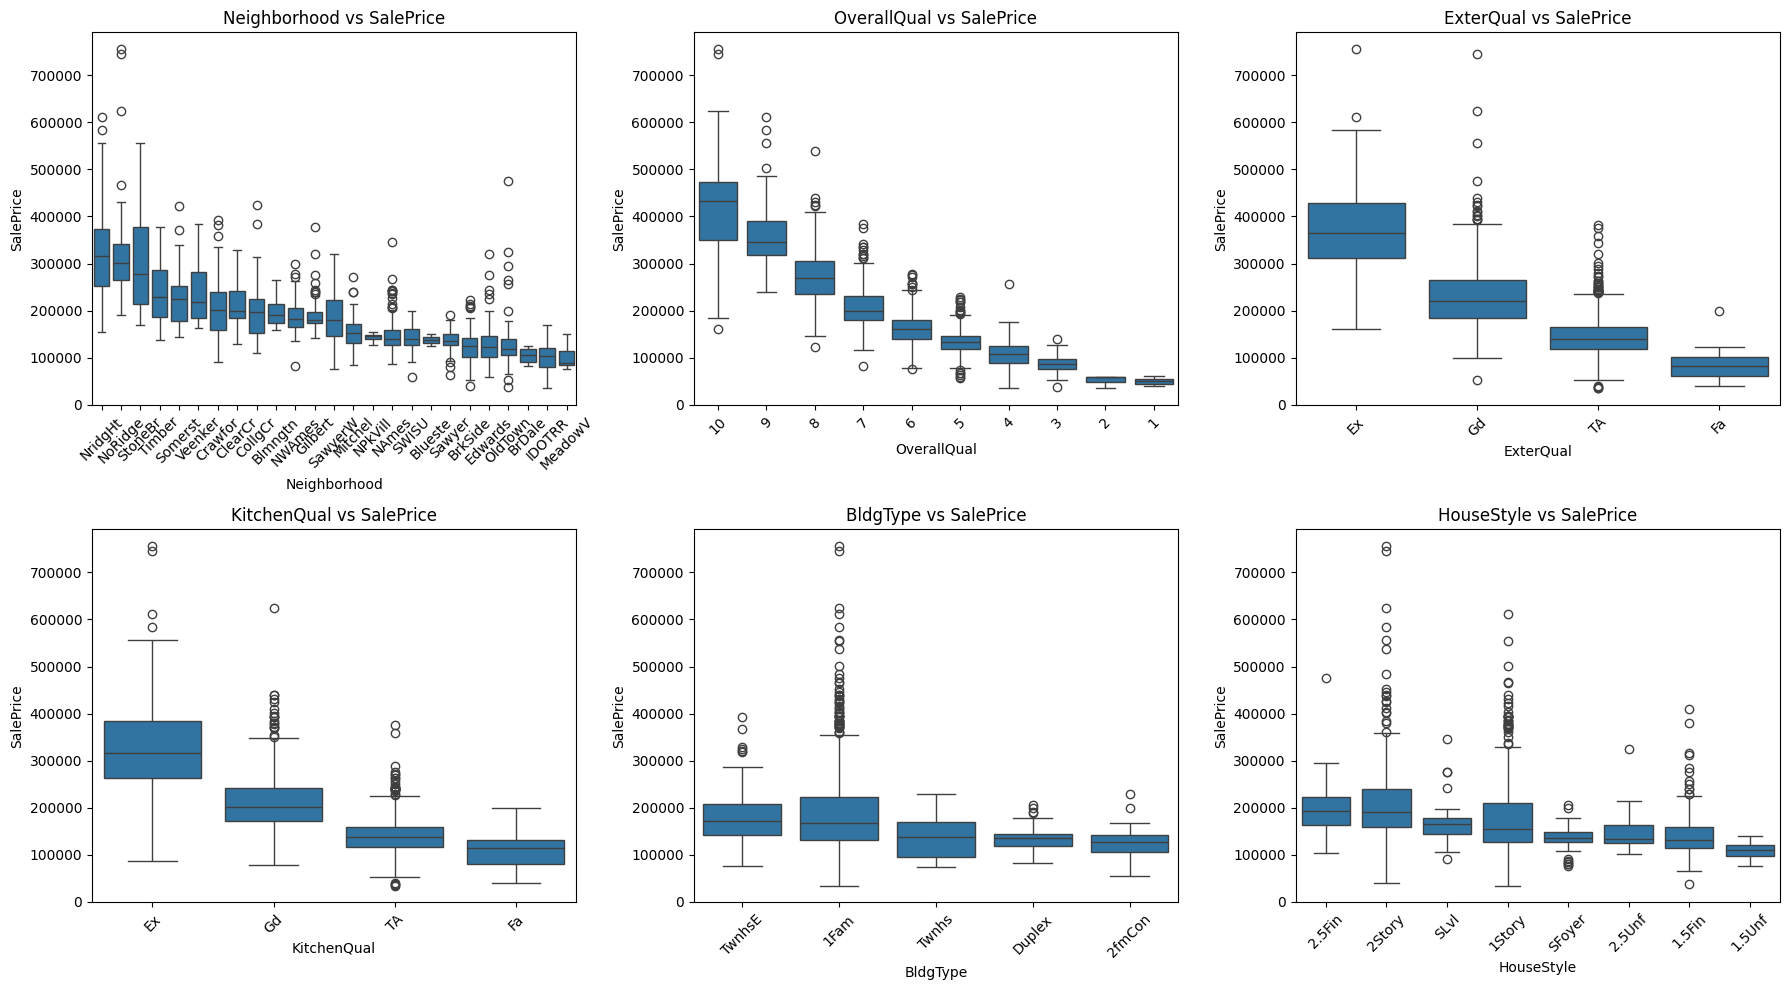

In [60]:
top_cats = ['Neighborhood', 'OverallQual', 'ExterQual', 'KitchenQual', 'BldgType', 'HouseStyle']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_cats):
    order = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='SalePrice', order=order, ax=axes[i])
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

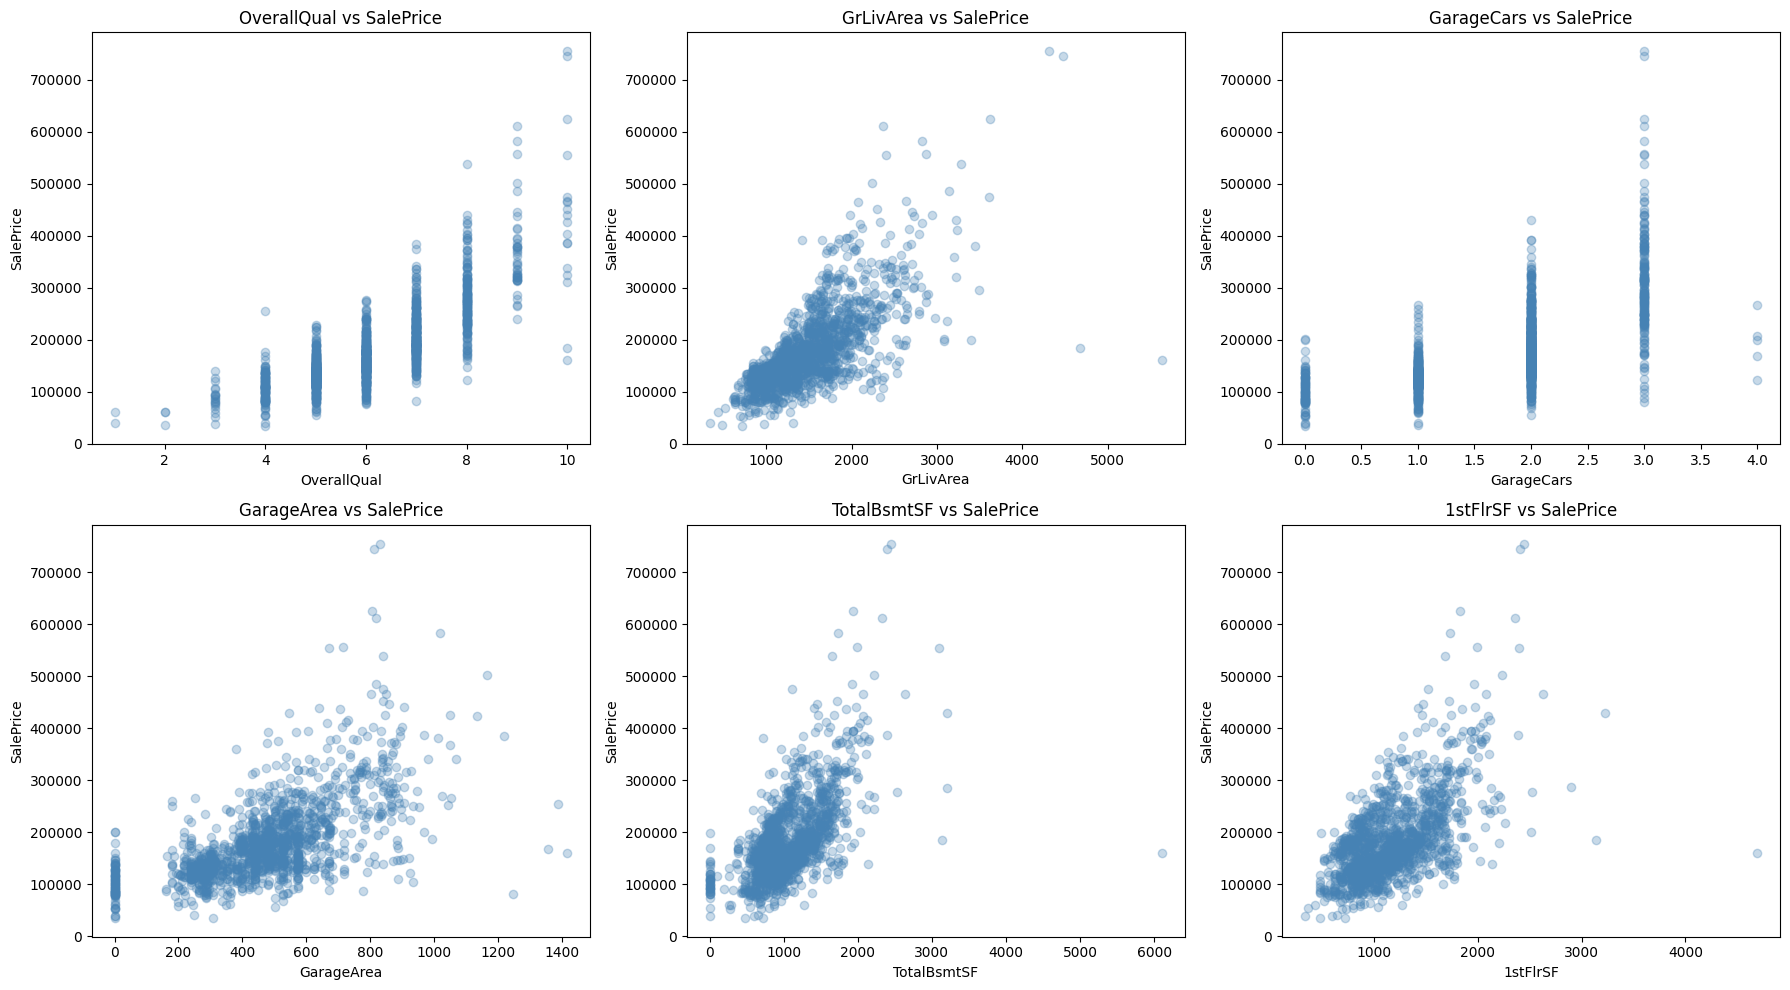

In [61]:
top_num = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_num):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.3, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()

In [62]:
print("=== EDA SUMMARY ===")
print(f"\nTotal samples: {len(df)}")
print(f"Total features: {df.shape[1] - 1}")
print(f"Features with missing values: {(df.isnull().sum() > 0).sum()}")
print(f"\nNumerical features: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"Categorical features: {len(df.select_dtypes(include='object').columns)}")
print(f"\nTop 5 correlations with SalePrice:")
print(correlations.head(5).to_string())
print(f"\nSalePrice range: ${df['SalePrice'].min():,.0f} — ${df['SalePrice'].max():,.0f}")
print(f"Mean:   ${df['SalePrice'].mean():,.0f}")
print(f"Median: ${df['SalePrice'].median():,.0f}")

=== EDA SUMMARY ===

Total samples: 1460
Total features: 80
Features with missing values: 19

Numerical features: 38
Categorical features: 43

Top 5 correlations with SalePrice:
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581

SalePrice range: $34,900 — $755,000
Mean:   $180,921
Median: $163,000


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22392\2776900125.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Categorical features: {len(df.select_dtypes(include='object').columns)}")
